# **Image Dehazing Using Pix2Pix GAN**

## **Overview**

Image dehazing is the process of removing haze from an image to recover a clearer and more visually informative version of the scene. Haze can reduce image visibility, contrast, and overall image quality.

This project uses a **Pix2Pix Generative Adversarial Network (GAN)** to perform **image-to-image translation from hazy images to clear images**.

Pix2Pix is a suitable choice for this task because it is designed for **paired image-to-image translation**, where each hazy image has a corresponding clear image of the same scene.

The project uses the **RESIDE-6K dataset**, containing 6,000 paired hazy and clear images for training and 1,000 paired images for testing. All images are RGB with a resolution of **400 × 400 pixels**.

The model was trained for **170 epochs** using a Generator and Discriminator. The project covers data exploration, preprocessing, Pix2Pix architecture, model training, generated results, and quantitative evaluation using **PSNR and SSIM**.


# The model was trained for 170 epochs. The training cells used during the iterative training and checkpoint resumption were consolidated to keep the notebook clean and avoid duplicated code

## **Dataset**

The project uses the **RESIDE-6K** dataset for image dehazing.

### **Dataset Verification**

The dataset was verified before starting the preprocessing stage.

* **Training set:** 6,000 hazy images paired with 6,000 ground-truth clear images.
* **Test set:** 1,000 hazy images paired with 1,000 ground-truth clear images.
* Hazy and ground-truth filenames are fully matched in both sets.
* All images have a resolution of **400 × 400 pixels**.
* All images are **RGB**.

The dataset structure and paired images are suitable for training and evaluating a **Pix2Pix** model for image dehazing.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("kmljts/reside-6k")

print("Path to dataset files:", path)

100%|██████████| 1.48G/1.48G [00:21<00:00, 74.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kmljts/reside-6k/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

1/
  RESIDE-6K/
    test/
    train/


In [ ]:
for folder in ["train", "test"]:
    folder_path = os.path.join(path, "RESIDE-6K", folder)

    print(f"\n{folder.upper()}:")
    print(os.listdir(folder_path))


TRAIN:
['GT', 'hazy']

TEST:
['GT', 'hazy']


In [ ]:
import os
from PIL import Image

train_hazy = os.path.join(path, "RESIDE-6K", "train", "hazy")
train_gt = os.path.join(path, "RESIDE-6K", "train", "GT")

test_hazy = os.path.join(path, "RESIDE-6K", "test", "hazy")
test_gt = os.path.join(path, "RESIDE-6K", "test", "GT")


def get_image_files(folder):
    return sorted([
        file for file in os.listdir(folder)
        if file.lower().endswith((".png", ".jpg", ".jpeg"))
    ])


train_hazy_files = get_image_files(train_hazy)
train_gt_files = get_image_files(train_gt)

test_hazy_files = get_image_files(test_hazy)
test_gt_files = get_image_files(test_gt)


print("Train Hazy:", len(train_hazy_files))
print("Train GT:", len(train_gt_files))
print("Test Hazy:", len(test_hazy_files))
print("Test GT:", len(test_gt_files))

print("\nTrain filenames match:", train_hazy_files == train_gt_files)
print("Test filenames match:", test_hazy_files == test_gt_files)

Train Hazy: 6000
Train GT: 6000
Test Hazy: 1000
Test GT: 1000

Train filenames match: True
Test filenames match: True


In [ ]:
sample_hazy = Image.open(os.path.join(train_hazy, train_hazy_files[0]))
sample_gt = Image.open(os.path.join(train_gt, train_gt_files[0]))

print("Hazy image size:", sample_hazy.size)
print("GT image size:", sample_gt.size)
print("Hazy image mode:", sample_hazy.mode)
print("GT image mode:", sample_gt.mode)

Hazy image size: (400, 400)
GT image size: (400, 400)
Hazy image mode: RGB
GT image mode: RGB


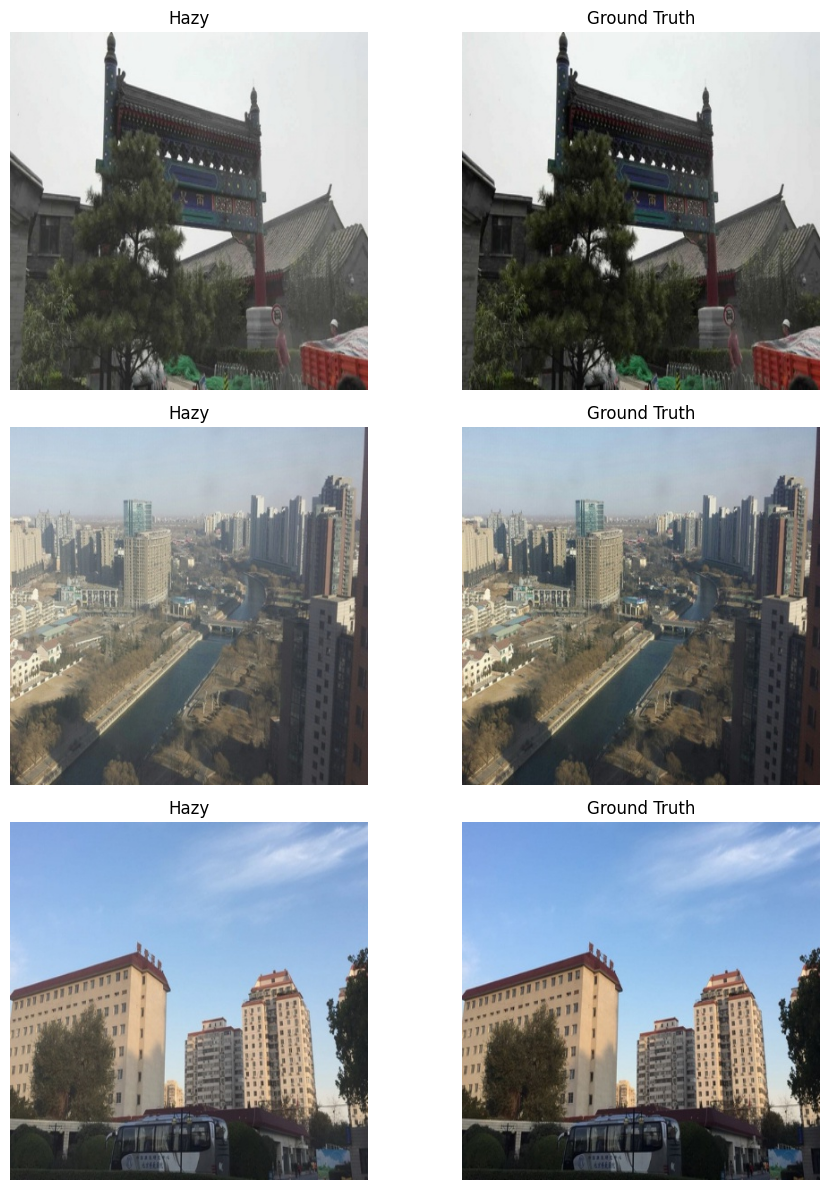

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i in range(3):
    hazy_image = Image.open(os.path.join(train_hazy, train_hazy_files[i]))
    gt_image = Image.open(os.path.join(train_gt, train_gt_files[i]))

    axes[i, 0].imshow(hazy_image)
    axes[i, 0].set_title("Hazy")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_image)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [ ]:
from torch.utils.data import Dataset


class DehazingDataset(Dataset):
    def __init__(self, hazy_dir, gt_dir, transform=None):
        self.hazy_dir = hazy_dir
        self.gt_dir = gt_dir
        self.transform = transform

        self.hazy_files = get_image_files(hazy_dir)
        self.gt_files = get_image_files(gt_dir)

    def __len__(self):
        return len(self.hazy_files)

    def __getitem__(self, index):
        hazy_path = os.path.join(self.hazy_dir, self.hazy_files[index])
        gt_path = os.path.join(self.gt_dir, self.gt_files[index])

        hazy_image = Image.open(hazy_path).convert("RGB")
        gt_image = Image.open(gt_path).convert("RGB")

        if self.transform:
            hazy_image = self.transform(hazy_image)
            gt_image = self.transform(gt_image)

        return hazy_image, gt_image

In [ ]:
train_dataset = DehazingDataset(
    train_hazy,
    train_gt,
    transform=transform
)

test_dataset = DehazingDataset(
    test_hazy,
    test_gt,
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 6000
Test samples: 1000


In [ ]:
hazy, gt = train_dataset[0]

print("Hazy shape:", hazy.shape)
print("GT shape:", gt.shape)
print("Hazy range:", hazy.min().item(), "to", hazy.max().item())
print("GT range:", gt.min().item(), "to", gt.max().item())

Hazy shape: torch.Size([3, 256, 256])
GT shape: torch.Size([3, 256, 256])
Hazy range: -0.8352941274642944 to 0.929411768913269
GT range: -0.9686274528503418 to 0.9450980424880981


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [ ]:
import torch
import torch.nn as nn


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=False):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.e1 = EncoderBlock(3, 64, normalize=False)
        self.e2 = EncoderBlock(64, 128)
        self.e3 = EncoderBlock(128, 256)
        self.e4 = EncoderBlock(256, 512)
        self.e5 = EncoderBlock(512, 512)
        self.e6 = EncoderBlock(512, 512)
        self.e7 = EncoderBlock(512, 512)
        self.e8 = EncoderBlock(512, 512)

        # Decoder
        self.d1 = DecoderBlock(512, 512, dropout=True)
        self.d2 = DecoderBlock(1024, 512, dropout=True)
        self.d3 = DecoderBlock(1024, 512, dropout=True)
        self.d4 = DecoderBlock(1024, 512)
        self.d5 = DecoderBlock(1024, 256)
        self.d6 = DecoderBlock(512, 128)
        self.d7 = DecoderBlock(256, 64)

        # Final layer
        self.final = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                3,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):

        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        e8 = self.e8(e7)

        # Decoder
        d1 = self.d1(e8)
        d1 = torch.cat([d1, e7], dim=1)

        d2 = self.d2(d1)
        d2 = torch.cat([d2, e6], dim=1)

        d3 = self.d3(d2)
        d3 = torch.cat([d3, e5], dim=1)

        d4 = self.d4(d3)
        d4 = torch.cat([d4, e4], dim=1)

        d5 = self.d5(d4)
        d5 = torch.cat([d5, e3], dim=1)

        d6 = self.d6(d5)
        d6 = torch.cat([d6, e2], dim=1)

        d7 = self.d7(d6)
        d7 = torch.cat([d7, e1], dim=1)

        output = self.final(d7)

        return output

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Input: Hazy + Clear
            EncoderBlock(6, 64, normalize=False),

            EncoderBlock(64, 128),

            EncoderBlock(128, 256),

            EncoderBlock(256, 512),

            nn.Conv2d(
                512,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, hazy, clear):
        x = torch.cat([hazy, clear], dim=1)

        return self.model(x)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
adversarial_loss = nn.BCEWithLogitsLoss()
reconstruction_loss = nn.L1Loss()

In [ ]:
lr = 0.0002
beta1 = 0.5
beta2 = 0.999

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(beta1, beta2)
)

In [ ]:
LAMBDA_L1 = 100

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/Pix2Pix_Dehazing/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Checkpoint directory: /content/drive/MyDrive/Pix2Pix_Dehazing/checkpoints


In [ ]:
def save_checkpoint(
    epoch,
    generator,
    discriminator,
    optimizer_G,
    optimizer_D,
    generator_loss,
    discriminator_loss,
    best_psnr
):

    checkpoint = {
        "epoch": epoch,

        "generator_state_dict":
            generator.state_dict(),

        "discriminator_state_dict":
            discriminator.state_dict(),

        "optimizer_G_state_dict":
            optimizer_G.state_dict(),

        "optimizer_D_state_dict":
            optimizer_D.state_dict(),

        "generator_loss":
            generator_loss,

        "discriminator_loss":
            discriminator_loss,

        "best_psnr":
            best_psnr
    }

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        "latest_checkpoint.pth"
    )

    torch.save(
        checkpoint,
        checkpoint_path
    )

In [ ]:
NUM_EPOCHS = 50
START_EPOCH = 1

In [ ]:
generator_losses = []
discriminator_losses = []

psnr_history = []
ssim_history = []
l1_history = []

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

In [ ]:
def evaluate_model(generator, test_loader, device):

    generator.eval()

    total_psnr = 0.0
    total_ssim = 0.0
    total_l1 = 0.0

    with torch.no_grad():

        for hazy, gt in test_loader:

            hazy = hazy.to(device)
            gt = gt.to(device)

            generated = generator(hazy)

            # Convert from [-1, 1] to [0, 1]
            generated = (generated + 1) / 2
            gt = (gt + 1) / 2

            generated_np = generated.cpu().numpy()
            gt_np = gt.cpu().numpy()

            for i in range(generated_np.shape[0]):

                generated_img = np.transpose(
                    generated_np[i],
                    (1, 2, 0)
                )

                gt_img = np.transpose(
                    gt_np[i],
                    (1, 2, 0)
                )

                total_psnr += peak_signal_noise_ratio(
                    gt_img,
                    generated_img,
                    data_range=1.0
                )

                total_ssim += structural_similarity(
                    gt_img,
                    generated_img,
                    data_range=1.0,
                    channel_axis=2
                )

            total_l1 += torch.mean(
                torch.abs(generated - gt)
            ).item()

    num_images = len(test_loader.dataset)
    num_batches = len(test_loader)

    avg_psnr = total_psnr / num_images
    avg_ssim = total_ssim / num_images
    avg_l1 = total_l1 / num_batches

    return avg_psnr, avg_ssim, avg_l1

In [ ]:
HISTORY_PATH = os.path.join(
    "/content/drive/MyDrive/Pix2Pix_Dehazing",
    "training_history.csv"
)

if not os.path.exists(HISTORY_PATH):

    with open(HISTORY_PATH, "w", newline="") as file:

        writer = csv.writer(file)

        writer.writerow([
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "psnr",
            "ssim",
            "l1"
        ])

In [ ]:
def save_history(
    epoch,
    generator_loss,
    discriminator_loss,
    psnr,
    ssim,
    l1
):

    with open(HISTORY_PATH, "a", newline="") as file:

        writer = csv.writer(file)

        writer.writerow([
            epoch,
            generator_loss,
            discriminator_loss,
            psnr,
            ssim,
            l1
        ])

In [ ]:
BEST_PSNR = -float("inf")

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_generator_psnr.pth"
)

In [ ]:
def load_checkpoint(checkpoint_path, generator, discriminator, optimizer_G, optimizer_D, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G_state_dict"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D_state_dict"])

    return checkpoint["epoch"] + 1

In [ ]:
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_generator_psnr.pth")

if os.path.exists(CHECKPOINT_PATH):
    print("Found latest checkpoint! Loading full state (G, D, Optimizers)...")
    START_EPOCH = load_checkpoint(
        CHECKPOINT_PATH,
        generator,
        discriminator,
        optimizer_G,
        optimizer_D,
        device
    )
    print(f"Resuming training smoothly from Epoch {START_EPOCH}")

elif os.path.exists(BEST_MODEL_PATH):
    print("Latest checkpoint not found, but Best Generator exists. Loading Best G weights...")
    generator.load_state_dict(
        torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
    )
    START_EPOCH = 31
    print(f"Resuming training from Epoch {START_EPOCH} using Best Generator")

else:
    print("No checkpoints found. Starting from scratch...")
    START_EPOCH = 1

Found latest checkpoint! Loading full state (G, D, Optimizers)...
Resuming training smoothly from Epoch 171


In [ ]:
import os
import torch
from tqdm.auto import tqdm

START_EPOCH = 170
NUM_EPOCHS = 170


CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_generator_psnr.pth")


if os.path.exists(CHECKPOINT_PATH):
    print("Found latest checkpoint! Restoring full state (G, D, Optimizers)...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G_state_dict"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D_state_dict"])

    if "best_psnr" in checkpoint:
        BEST_PSNR = checkpoint["best_psnr"]
        print(f"✓ Restored highest achieved BEST_PSNR: {BEST_PSNR:.4f}")

    print(f"✓ Full state loaded! Running Epoch {START_EPOCH}...")

elif os.path.exists(BEST_MODEL_PATH):
    print("Latest checkpoint missing. Loading Best Generator weights...")
    generator.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False))
    print(f"✓ Best Generator loaded. Running Epoch {START_EPOCH}...")

else:
    print("⚠️ Warning: No checkpoint found in Drive!")

# ==========================================
# 4. Training Loop (Epoch 170 Only)
# ==========================================

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):

    generator.train()
    discriminator.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch}/{NUM_EPOCHS}]",
        leave=True
    )

    for hazy, gt in progress_bar:

        hazy = hazy.to(device)
        gt = gt.to(device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()

        fake_clear = generator(hazy)

        real_pair = discriminator(hazy, gt)
        fake_pair = discriminator(hazy, fake_clear.detach())

        real_labels = torch.ones_like(real_pair)
        fake_labels = torch.zeros_like(fake_pair)

        loss_D_real = adversarial_loss(real_pair, real_labels)
        loss_D_fake = adversarial_loss(fake_pair, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2

        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_G.zero_grad()

        fake_clear = generator(hazy)

        fake_pair = discriminator(hazy, fake_clear)

        loss_G_adv = adversarial_loss(fake_pair, real_labels)
        loss_G_L1 = reconstruction_loss(fake_clear, gt)

        loss_G = loss_G_adv + (LAMBDA_L1 * loss_G_L1)

        loss_G.backward()
        optimizer_G.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()

        # Update Progress Bar
        progress_bar.set_postfix(
            G=f"{loss_G.item():.4f}",
            D=f"{loss_D.item():.4f}"
        )

    # Average Losses
    epoch_g_loss /= len(train_loader)
    epoch_d_loss /= len(train_loader)

    # Evaluation
    psnr, ssim, l1 = evaluate_model(generator, test_loader, device)

    # Save History in Memory
    generator_losses.append(epoch_g_loss)
    discriminator_losses.append(epoch_d_loss)
    psnr_history.append(psnr)
    ssim_history.append(ssim)
    l1_history.append(l1)

    # Print Epoch Results
    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"G Loss: {epoch_g_loss:.4f} | "
        f"D Loss: {epoch_d_loss:.4f} | "
        f"PSNR: {psnr:.4f} | "
        f"SSIM: {ssim:.4f} | "
        f"L1: {l1:.4f}"
    )

    # Save History to Drive
    save_history(epoch, epoch_g_loss, epoch_d_loss, psnr, ssim, l1)


    if psnr > BEST_PSNR:
        BEST_PSNR = psnr
        torch.save(generator.state_dict(), BEST_MODEL_PATH)
        print(f"✓ Best Generator updated! New Peak PSNR: {BEST_PSNR:.4f}")

    # Save Latest Checkpoint in Drive
    save_checkpoint(
        epoch,
        generator,
        discriminator,
        optimizer_G,
        optimizer_D,
        epoch_g_loss,
        epoch_d_loss,
        BEST_PSNR
    )

print("🎉 Training process fully finished up to Epoch 170!")

Found latest checkpoint! Restoring full state (G, D, Optimizers)...
✓ Restored highest achieved BEST_PSNR: 25.9942
✓ Full state loaded! Running Epoch 170...


Epoch [170/170]:   0%|          | 0/375 [00:00<?, ?it/s]

KeyboardInterrupt: 

Loading best generator weights from: /content/drive/MyDrive/Pix2Pix_Dehazing/checkpoints/best_generator_psnr.pth
✓ Best Generator loaded successfully!

Evaluating model performance on the entire Test Set (1000 images)...

       FINAL TEST SET EVALUATION RESULTS       
 Average PSNR : 25.9942 dB
 Average SSIM : 0.9238
 Average L1   : 0.0421



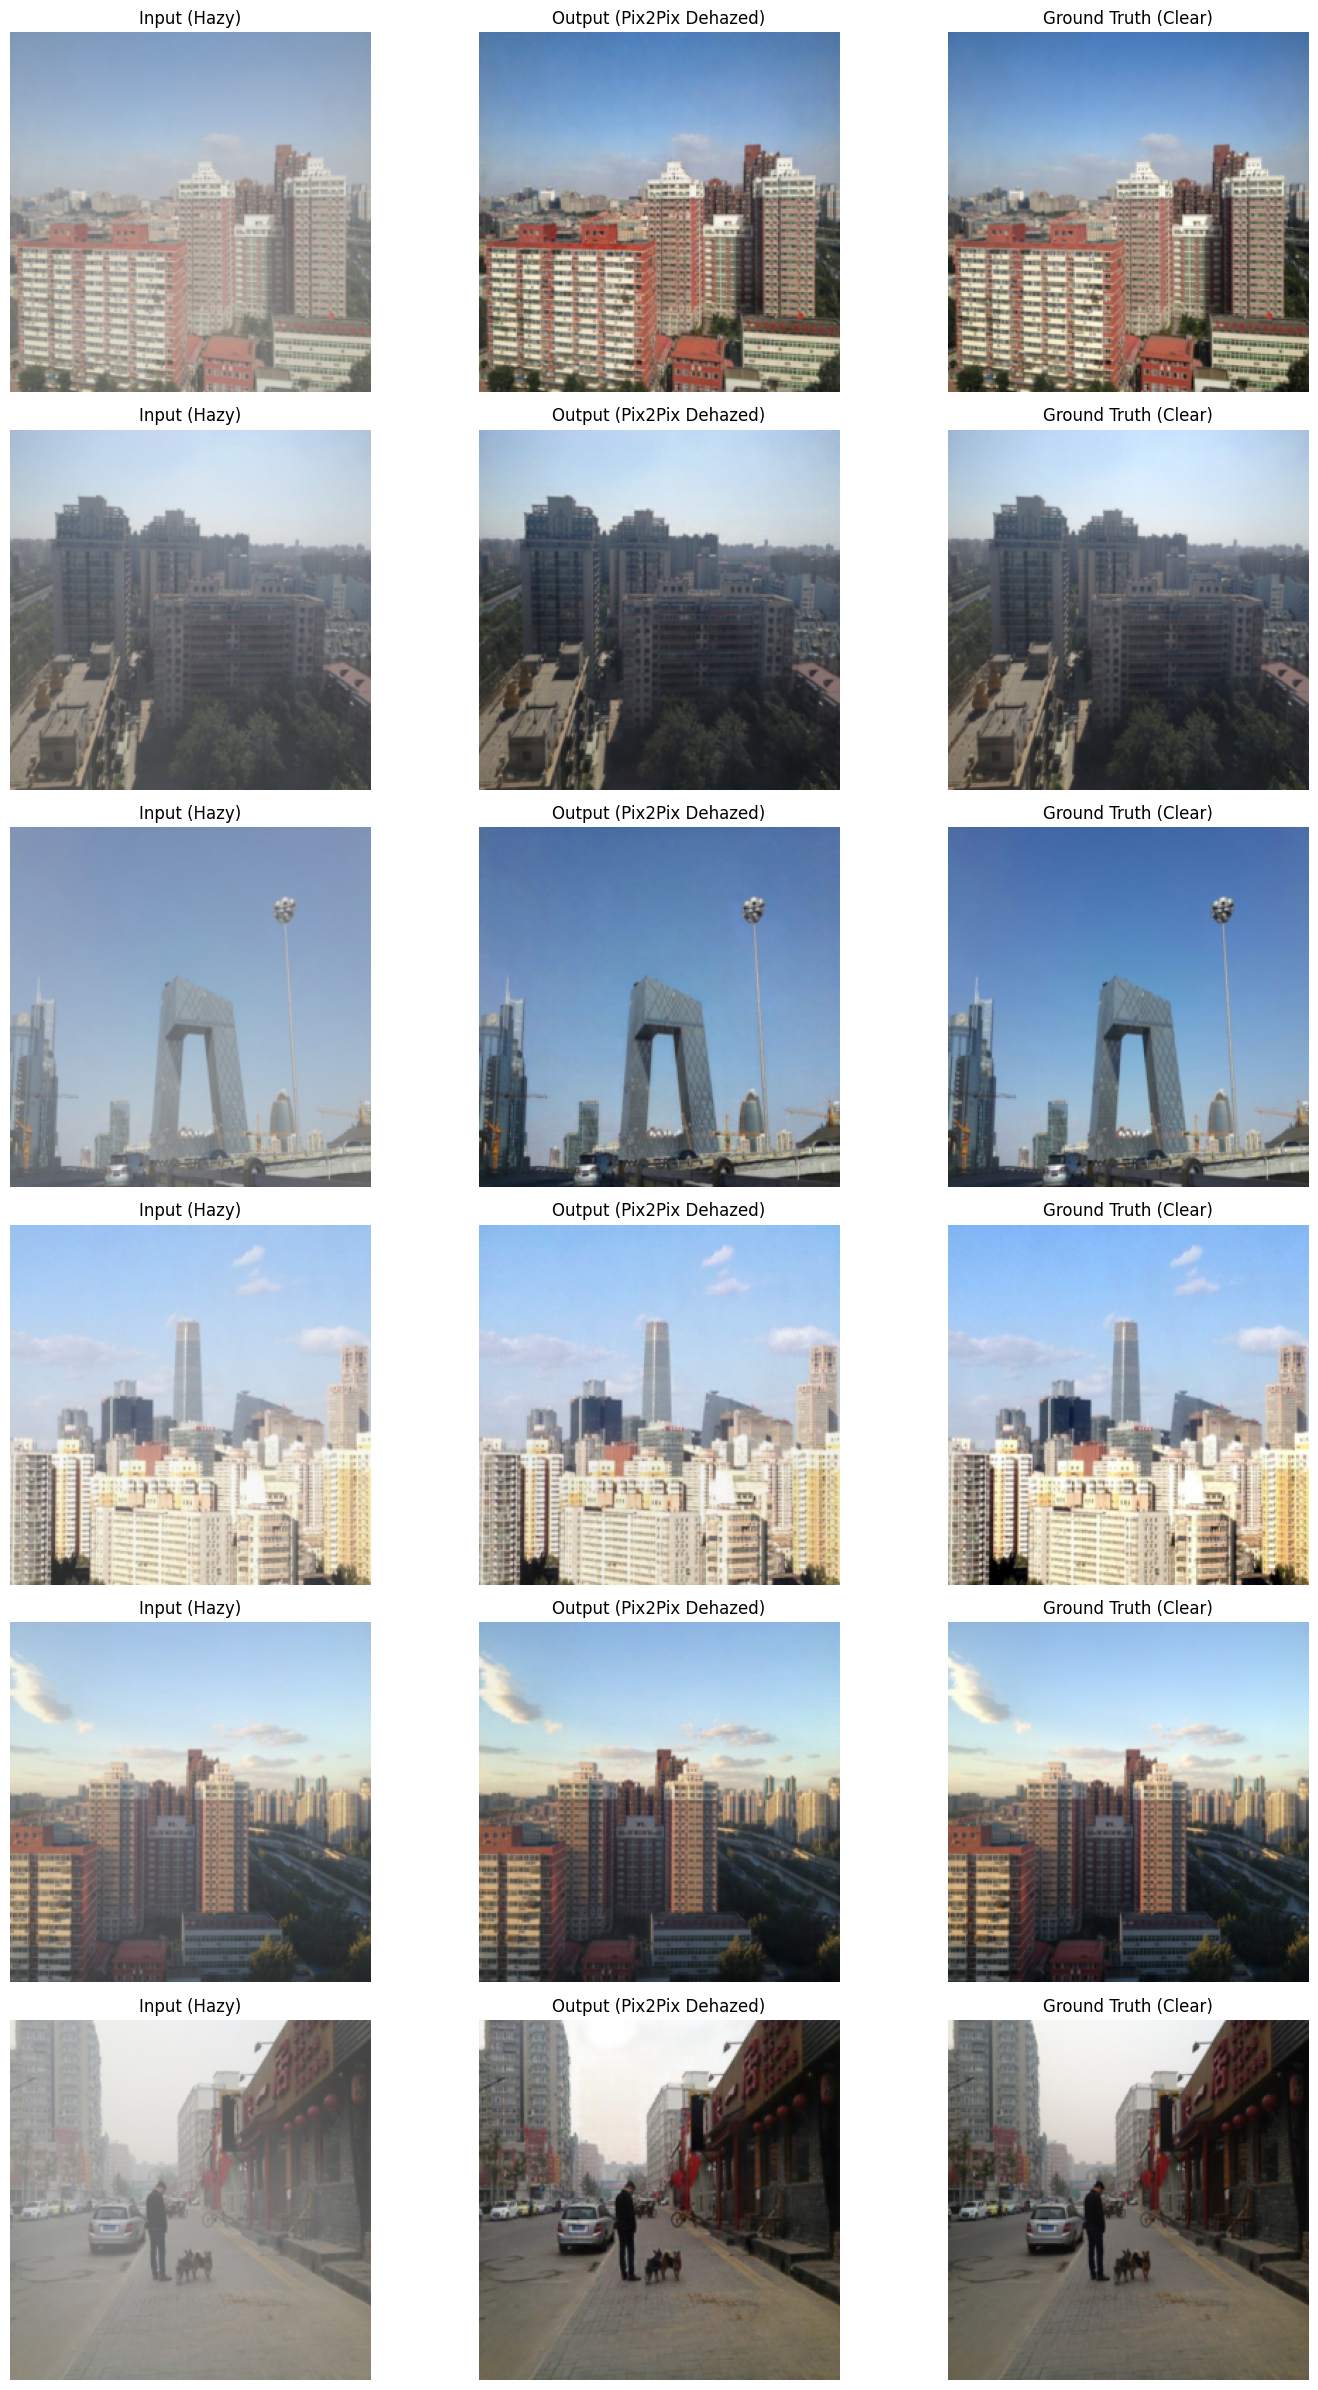

✓ Visual results plot saved to Drive as 'visual_test_results.png'


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_generator_psnr.pth")


if os.path.exists(BEST_MODEL_PATH):
    print(f"Loading best generator weights from: {BEST_MODEL_PATH}")
    generator.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False))
    generator.eval()
    print("✓ Best Generator loaded successfully!")
else:
    print(" Best model weights file not found! Please check BEST_MODEL_PATH.")



print("\nEvaluating model performance on the entire Test Set (1000 images)...")


avg_test_psnr, avg_test_ssim, avg_test_l1 = evaluate_model(generator, test_loader, device)

print("\n" + "="*50)
print("       FINAL TEST SET EVALUATION RESULTS       ")
print("="*50)
print(f" Average PSNR : {avg_test_psnr:.4f} dB")
print(f" Average SSIM : {avg_test_ssim:.4f}")
print(f" Average L1   : {avg_test_l1:.4f}")
print("="*50 + "\n")



def denormalize(tensor):

    tensor = (tensor + 1.0) / 2.0
    return torch.clamp(tensor, 0.0, 1.0)


num_samples_to_show = 6
generator.eval()


data_iter = iter(test_loader)
hazy_batch, gt_batch = next(data_iter)

hazy_batch = hazy_batch.to(device)
gt_batch = gt_batch.to(device)

with torch.no_grad():
    fake_batch = generator(hazy_batch)


hazy_imgs = denormalize(hazy_batch).cpu().permute(0, 2, 3, 1).numpy()
fake_imgs = denormalize(fake_batch).cpu().permute(0, 2, 3, 1).numpy()
gt_imgs = denormalize(gt_batch).cpu().permute(0, 2, 3, 1).numpy()


fig, axes = plt.subplots(num_samples_to_show, 3, figsize=(15, 4 * num_samples_to_show))

for i in range(min(num_samples_to_show, len(hazy_imgs))):
    # Hazy Input
    axes[i, 0].imshow(hazy_imgs[i])
    axes[i, 0].set_title("Input (Hazy)")
    axes[i, 0].axis("off")

    # Pix2Pix Output
    axes[i, 1].imshow(fake_imgs[i])
    axes[i, 1].set_title("Output (Pix2Pix Dehazed)")
    axes[i, 1].axis("off")

    # Ground Truth
    axes[i, 2].imshow(gt_imgs[i])
    axes[i, 2].set_title("Ground Truth (Clear)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "visual_test_results.png"), dpi=300)
plt.show()

print("✓ Visual results plot saved to Drive as 'visual_test_results.png'")

In [ ]:
!pip install -q gradio

In [ ]:
# =========================
# Gradio Interface
# =========================

with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="slate"),
    title="Image Dehazing AI",
    css="""
    .image-container {width: 350px !important; height: 350px !important; max-width: 350px !important; max-height: 350px !important;}
    .image-container img {object-fit: contain !important; width: 100% !important; height: 100% !important;}
    """,
) as demo:

  gr.Markdown(
      """
        # 🌫️ Image Dehazing AI

        ### Remove haze and restore image clarity using Pix2Pix GAN
        """
  )

  gr.Markdown(
      "Upload a hazy image and let the trained Pix2Pix model generate a clearer"
      " version."
  )

  with gr.Row():
    input_image = gr.Image(
        type="pil",
        label="Hazy Image",
        elem_classes="image-container",
        sources=["upload", "clipboard"],
    )

    output_image = gr.Image(
        type="pil", label="Dehazed Image", elem_classes="image-container"
    )

  dehaze_button = gr.Button("✨ Dehaze Image", variant="primary")

  dehaze_button.click(fn=dehaze_image, inputs=input_image, outputs=output_image)

  gr.Markdown(
      """
        ---
        **Model:** Pix2Pix GAN
        **Task:** Hazy → Clear Image
        **Input Size:** 256 × 256
        """
  )


# =========================
# Launch
# =========================

demo.launch()

/tmp/ipykernel_535/1166952515.py:5: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fb8f2f6af92f1c77b5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
